# Install dan Import Library

In [1]:
!pip install split-folders

In [2]:
import os
import splitfolders
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Data Loading

In [3]:
from google.colab import files
files.upload() # Upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ylndwlndr","key":"e23cbf8950313429ad0af061fc0554ab"}'}

In [4]:
!mkdir -p ~/.kaggle
# Copy kaggle.json
!cp kaggle.json ~/.kaggle/
# Ubah permission
!chmod 600 ~/.kaggle/kaggle.json
# Download dataset
!kaggle datasets download -d alessiocorrado99/animals10
# Unzip dataset
!unzip -q animals10.zip

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:07<00:00, 84.1MB/s]



# Dataset Cheking

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

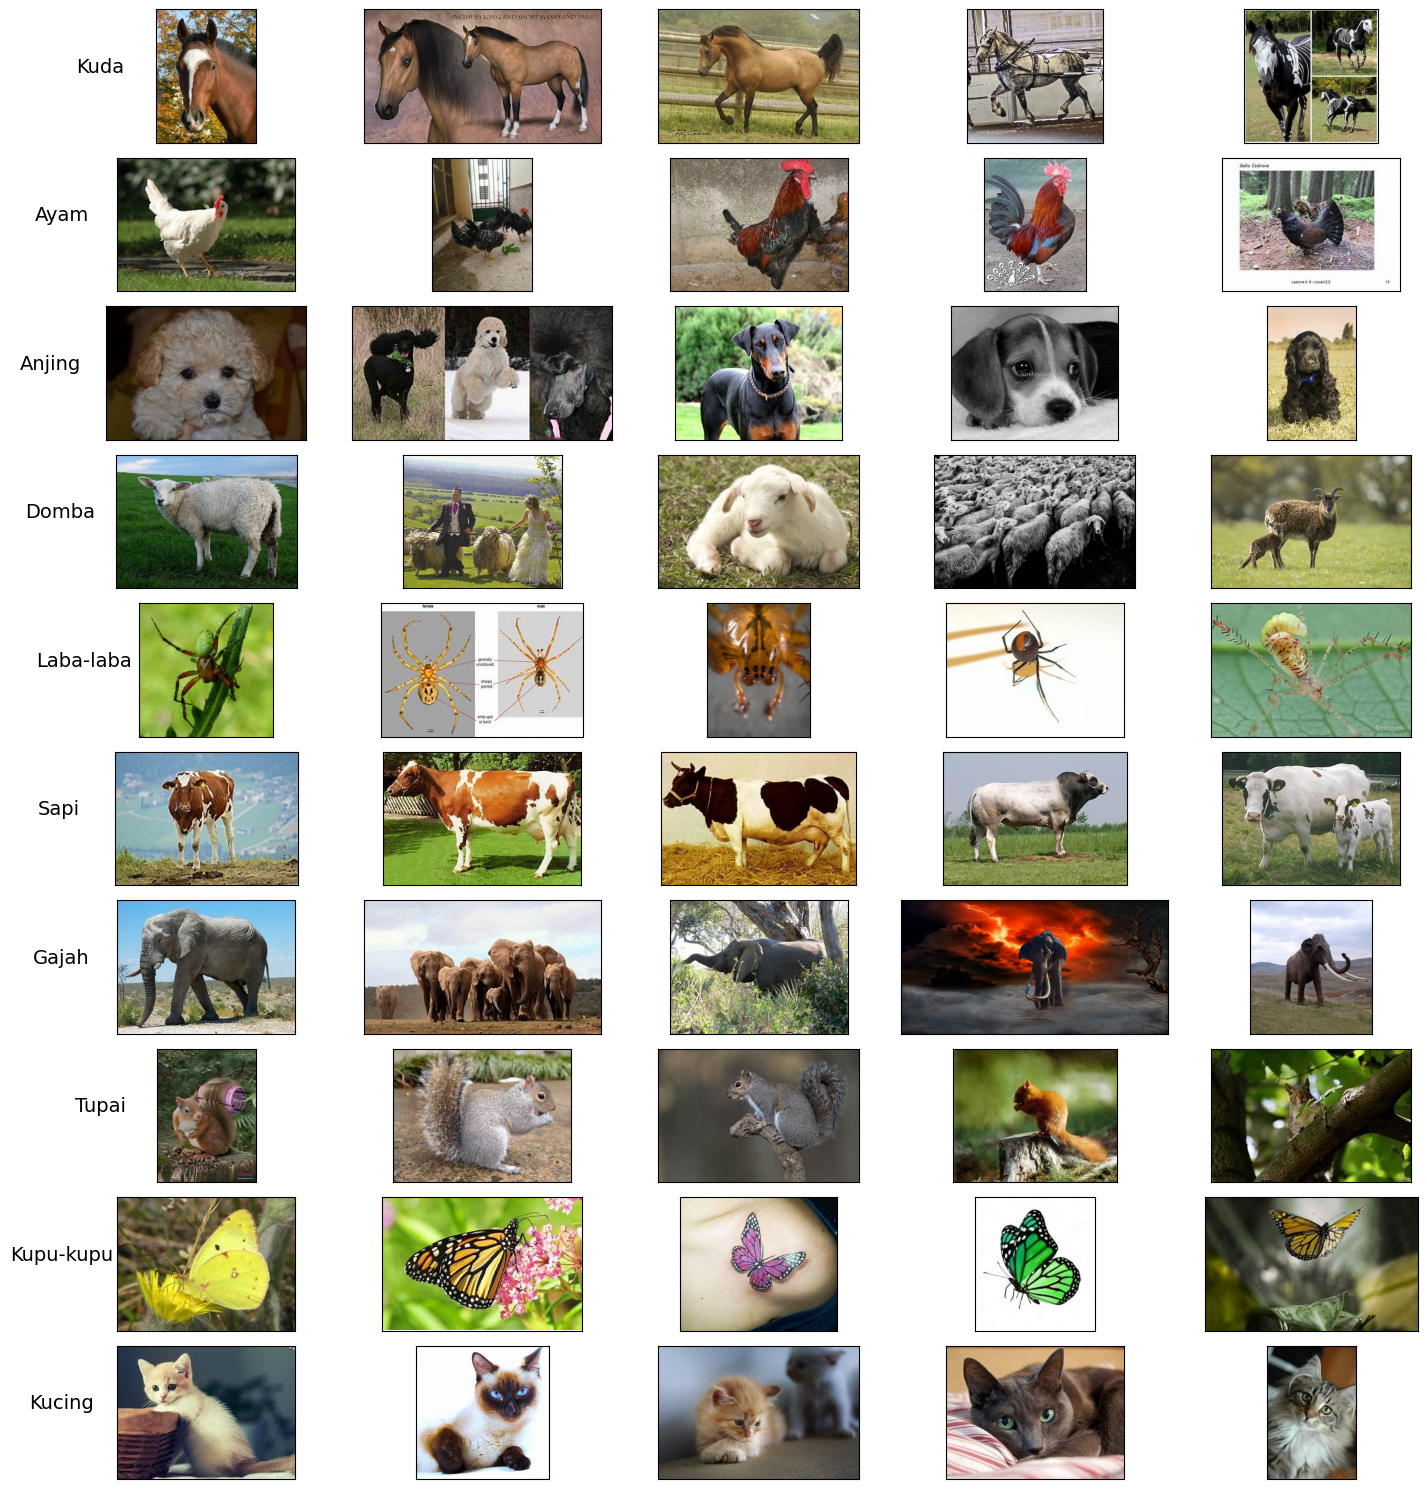

In [6]:
# Path dataset
base_dir = '/content/raw-img'

# Dictionary translate Italia ke Indonesia
translate = {
    "cane": "Anjing",
    "cavallo": "Kuda",
    "elefante": "Gajah",
    "farfalla": "Kupu-kupu",
    "gallina": "Ayam",
    "gatto": "Kucing",
    "mucca": "Sapi",
    "pecora": "Domba",
    "scoiattolo": "Tupai",
    "ragno": "Laba-laba"
}

# Simpan daftar gambar tiap kelas
animal_images = {}

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)

    if os.path.isdir(class_path):
        animal_images[class_name] = os.listdir(class_path)

# Tampilkan contoh gambar
classes = list(animal_images.keys())
fig, axs = plt.subplots(len(classes), 5, figsize=(15, 15))

for i, class_name_it in enumerate(classes):
    class_path = os.path.join(base_dir, class_name_it)

    # Translate ke Inggris
    class_name_en = translate.get(class_name_it, class_name_it)

    images = np.random.choice(animal_images[class_name_it], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(class_path, image_name)
        img = Image.open(img_path)

        axs[i, j].imshow(img)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])

    # Kasih label di gambar paling kiri aja
    axs[i, 0].set_ylabel(class_name_en, fontsize=14, rotation=0, labelpad=40)

plt.tight_layout()
plt.show()

# Plot Distribusi

In [7]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

Total File : 26179
{'Kuda': 2623, 'Ayam': 3098, 'Anjing': 4863, 'Domba': 1820, 'Laba-laba': 4821, 'Sapi': 1866, 'Gajah': 1446, 'Tupai': 1862, 'Kupu-kupu': 2112, 'Kucing': 1668}


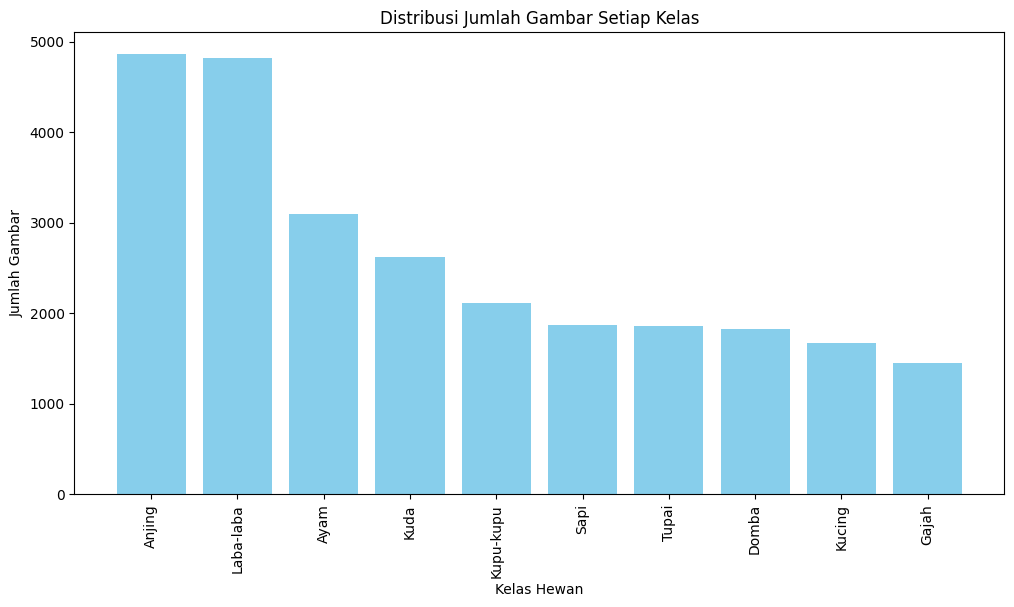

In [8]:
import collections

# Path dataset
base_dir = '/content/raw-img'

# Hitung jumlah gambar tiap kelas
number_label = {}
total_files = 0

for class_name_it in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name_it)
    if os.path.isdir(class_path):
        counting = len(os.listdir(class_path))

        # Translate ke Indonesia
        class_name_id = translate.get(class_name_it, class_name_it)
        number_label[class_name_id] = counting
        total_files += counting

print("Total File : " + str(total_files))
print(number_label)

# Sort the labels by count
sorted_labels = collections.OrderedDict(sorted(number_label.items(), key=lambda x: x[1], reverse=True))

# Plot distribusi
plt.figure(figsize=(12, 6))
plt.bar(sorted_labels.keys(), sorted_labels.values(), color='skyblue')
plt.xticks(rotation=90)
plt.title("Distribusi Jumlah Gambar Setiap Kelas")
plt.xlabel("Kelas Hewan")
plt.ylabel("Jumlah Gambar")
plt.show()

# Data Spliting

In [9]:
# Split data: 80% train, 10% validation, 10% test

splitfolders.ratio(
    base_dir,
    output="dataset_split",
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

train_dir = '/content/dataset_split/train'
val_dir = '/content/dataset_split/val'
test_dir = '/content/dataset_split/test'

Copying files: 26179 files [00:04, 5612.32 files/s]


# Image Data Generator

In [10]:
# IMAGE_SIZE = (128, 1628)
IMAGE_SIZE = (160, 160) # dinaikin ukurannya
BATCH_SIZE = 32
SEED = 999
NUM_CLASSES = 10

In [11]:
# Karena akurasinya jelek kalo pake scratch, saya coba ganti pakai tranfer learning "MobileNetV2"
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    #rescale=1./255,
    # diganti pake punya MobileNetV2
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

#test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_data = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 20938 images belonging to 10 classes.
Found 2614 images belonging to 10 classes.
Found 2627 images belonging to 10 classes.


# Model

In [13]:
# BASE MODEL

base_model = tf.keras.applications.MobileNetV2(
    #input_shape=(128,128,3),
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

# Freeze pretrained layer
#base_model.trainable = False
# Jangan di freeze semua, buka sebagian layer biar akurasinya naik

# Freeze sebagian besar layer
for layer in base_model.layers[:-30]:
    layer.trainable = False

# sequential
cnn_model = tf.keras.models.Sequential([
    # CNN Layer
    base_model,

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
# COMPILE

cnn_model.compile(
    #loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam( # optimizer pakai Adam
        learning_rate=0.0001 # tidak usah besar-besar
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1 # tambah label smoothing buat bantu generalisasinya
    ),
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,632,170 (10.04 MB)

 Trainable params: 1,900,586 (7.25 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [15]:
# CALLBACKS

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
    ),

    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [16]:
# TRAINING

cnn_hist = cnn_model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=callbacks
)

Epoch 1/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 224s 296ms/step - accuracy: 0.7623 - loss: 1.1614 - val_accuracy: 0.9369 - val_loss: 0.7802 - learning_rate: 1.0000e-04
Epoch 2/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 160s 244ms/step - accuracy: 0.8989 - loss: 0.8775 - val_accuracy: 0.9422 - val_loss: 0.7761 - learning_rate: 1.0000e-04
Epoch 3/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 159s 242ms/step - accuracy: 0.9320 - loss: 0.7919 - val_accuracy: 0.9445 - val_loss: 0.7427 - learning_rate: 1.0000e-04
Epoch 4/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 158s 241ms/step - accuracy: 0.9453 - loss: 0.7504 - val_accuracy: 0.9522 - val_loss: 0.6863 - learning_rate: 1.0000e-04
Epoch 5/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 158s 241ms/step - accuracy: 0.9596 - loss: 0.7119 - val_accuracy: 0.9537 - val_loss: 0.6479 - learning_rate: 1.0000e-04
Epoch 6/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 157s 239ms/step - accuracy: 0.9651 - loss: 0.6894 - val_accuracy: 0.9529 - val_loss: 0.6428 - learning_rate: 1.0000e-04
Epoch 7/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 

# Evaluasi

In [17]:
# TEST AKURASI
test_loss, test_acc = cnn_model.evaluate(test_data)

# Ubah ke persen
test_acc_percent = test_acc * 100

print(f"\nTest Accuracy : {test_acc_percent:.2f}%")
print(f"Test Loss : {test_loss:.4f}")

83/83 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.9631 - loss: 0.6113

Test Accuracy : 96.31%
Test Loss : 0.6113


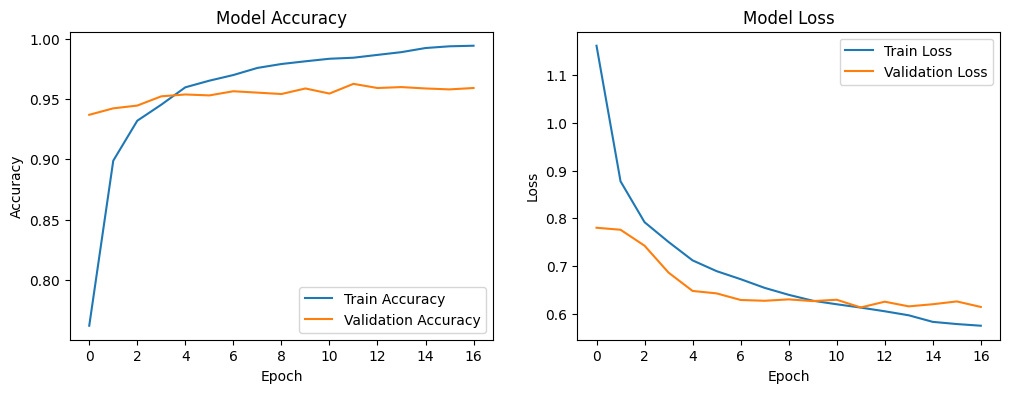

In [18]:
# PLOT AKURASI DAN LOSS
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(cnn_hist.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(cnn_hist.history['loss'], label='Train Loss')
plt.plot(cnn_hist.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step


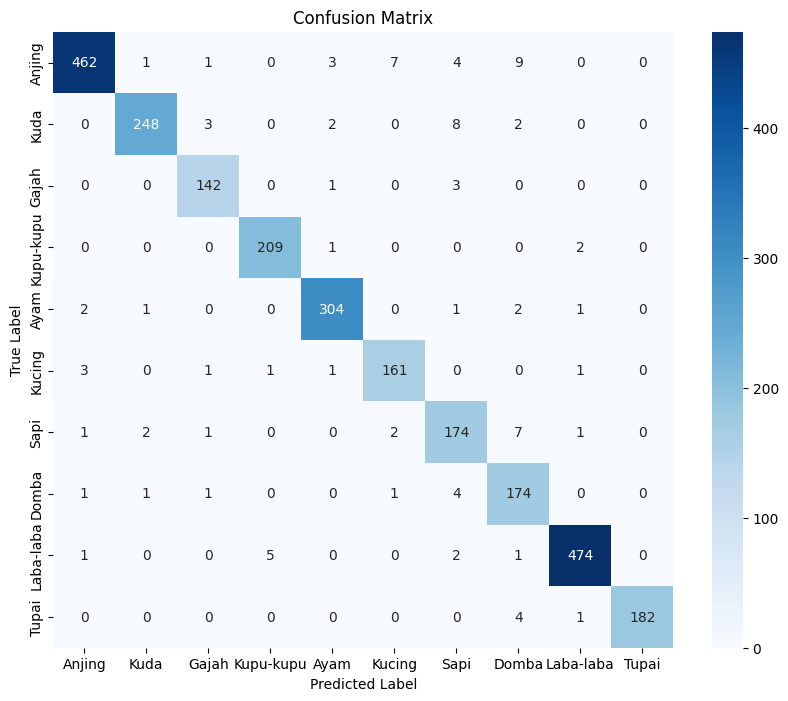

              precision    recall  f1-score   support

      Anjing       0.98      0.95      0.97       487
        Kuda       0.98      0.94      0.96       263
       Gajah       0.95      0.97      0.96       146
   Kupu-kupu       0.97      0.99      0.98       212
        Ayam       0.97      0.98      0.98       311
      Kucing       0.94      0.96      0.95       168
        Sapi       0.89      0.93      0.91       188
       Domba       0.87      0.96      0.91       182
   Laba-laba       0.99      0.98      0.98       483
       Tupai       1.00      0.97      0.99       187

    accuracy                           0.96      2627
   macro avg       0.96      0.96      0.96      2627
weighted avg       0.96      0.96      0.96      2627



In [19]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Prediksi test set
predictions = cnn_model.predict(test_data)
# Ambil class prediction
y_pred = np.argmax(predictions, axis=1)
# Label asli
y_true = test_data.classes
# Nama kelas ORI dari folder
class_name_it = list(test_data.class_indices.keys())
# Nama kelas di-translate ke Indonesia
class_name_id = [translate.get(name, name) for name in class_name_it]
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_name_id, yticklabels=class_name_id)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_name_id))

# Export Saved Model

In [20]:
import os
os.makedirs("Proyek_Klasifikasi_Gambar_Yolanda_Wulandari", exist_ok=True)
os.makedirs("Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/tfjs_model", exist_ok=True)
os.makedirs("Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/tflite", exist_ok=True)
os.makedirs("Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model", exist_ok=True)

In [21]:
cnn_model.export("Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model")

Saved artifact at 'Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138487801089296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138487801093904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138487801096208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138487801095824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138487801094672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138487801096400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138487801094864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138487801096976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138487801096592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138487801094480: TensorSpec(shape=(), dt

## Inference dengan Save Model

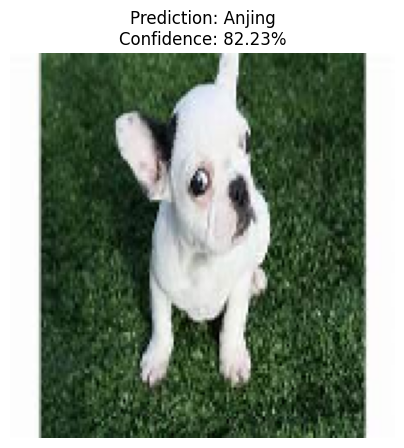

IMAGE CLASSIFICATION RESULT
Input Image     : /content/raw-img/cane/OIP-vVXO5rU68NdrUtH8gWb_wwHaEK.jpeg
Predicted Class : Anjing
Confidence      : 82.23%

Model successfully classified the image.


In [22]:
import numpy as np
from tensorflow.keras.preprocessing import image

# ==========================================
# LOAD SAVEDMODEL
# ==========================================

loaded_model = tf.saved_model.load(
    "Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model"
)

infer = loaded_model.signatures["serving_default"]

# ==========================================
# IMAGE FOR INFERENCE
# ==========================================

img_path = '/content/raw-img/cane/OIP-vVXO5rU68NdrUtH8gWb_wwHaEK.jpeg'

# Load image
img = image.load_img(
    img_path,
    target_size=(160,160)
)

# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(
    img_array,
    axis=0
)

# Preprocessing MobileNetV2
img_array = preprocess_input(img_array)

# ==========================================
# PREDICTION
# ==========================================

prediction = infer(tf.constant(img_array))

output = list(prediction.values())[0]

predicted_class = np.argmax(output)

confidence = float(
    np.max(output) * 100
)

class_names = list(
    train_data.class_indices.keys()
)

predicted_label = class_name_id[predicted_class]

# ==========================================
# DISPLAY RESULT
# ==========================================

plt.figure(figsize=(5,5))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%"
)

plt.axis('off')

plt.show()

# ==========================================
# PRINT RESULT
# ==========================================

print("===================================")
print("IMAGE CLASSIFICATION RESULT")
print("===================================")

print(f"Input Image     : {img_path}")
print(f"Predicted Class : {predicted_label}")
print(f"Confidence      : {confidence:.2f}%")

print("\nModel successfully classified the image.")

# Export Model TF-Lite

In [23]:
converter = tf.lite.TFLiteConverter.from_saved_model("Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model")

tflite_model = converter.convert()
with open("Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/tflite/model.tflite", "wb"
) as f:
    f.write(tflite_model)
print("TFLite model saved.")

TFLite model saved.


In [24]:
labels = list(train_data.class_indices.keys())

with open("Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/tflite/label.txt", "w"
) as f:

    for label in labels:
        f.write(label + "\n")
print("label.txt created")

label.txt created


# Export Model TFJS

In [25]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.6 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting u

In [26]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model \
    Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/tfjs_model

2026-05-11 12:40:36.008040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778503236.029838   15611 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778503236.036957   15611 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778503236.055170   15611 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778503236.055205   15611 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778503236.055210   15611 computation_placer.cc:177] computation placer alr

In [30]:
!zip -r Proyek_Klasifikasi_Gambar_Yolanda_Wulandari.zip Proyek_Klasifikasi_Gambar_Yolanda_Wulandari

from google.colab import files

files.download("Proyek_Klasifikasi_Gambar_Yolanda_Wulandari.zip")

  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/ (stored 0%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model/ (stored 0%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model/variables/ (stored 0%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model/variables/variables.index (deflated 78%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model/fingerprint.pb (stored 0%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model/saved_model.pb (deflated 91%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/saved_model/assets/ (stored 0%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/tfjs_model/ (stored 0%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/tfjs_model/group1-shard1of3.bin (deflated 7%)
  adding: Proyek_Klasifikasi_Gambar_Yolanda_Wulandari/tfjs_model/group1-shard3of3.bin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>